# Transient

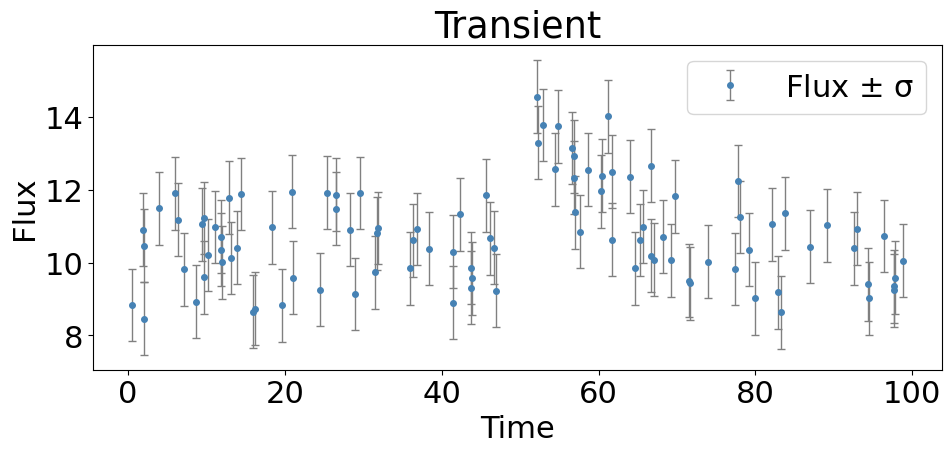

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

data = np.load("transient.npy")

time  = data[:, 0]   
flux  = data[:, 1]   
sigma = data[:, 2]   

fig, ax = plt.subplots(figsize=(10, 5))

ax.errorbar(
    time, flux, yerr=sigma, fmt="o", markersize=4, capsize=3, color="steelblue", ecolor="gray", elinewidth=1, label=f"Flux $\pm$ σ")

ax.set_xlabel("Time")
ax.set_ylabel("Flux")
ax.set_title("Transient")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
import emcee

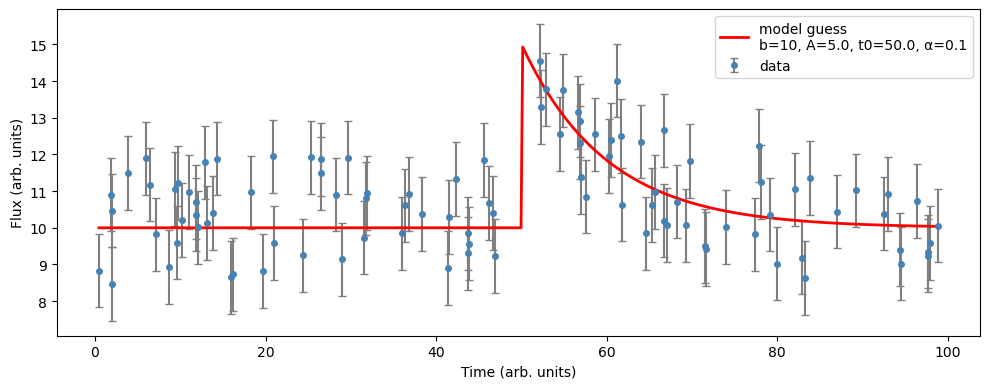

Log-likelihood con parametri iniziali: -51.49


In [18]:
def burst_model(t, b, A, t0, alpha):
    f = np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))
    return f


def log_likelihood(params, t, flux_obs, sigma):
    b, A, t0, alpha = params
    model = burst_model(t, b, A, t0, alpha)
    residuals = flux_obs - model
    return -0.5 * np.sum((residuals / sigma) ** 2)


params_guess = [10, 5.0, 50.0, 0.1]   

t_plot = np.linspace(time.min(), time.max(), 500)
f_plot = burst_model(t_plot, *params_guess)

fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(time, flux, yerr=sigma, fmt="o", markersize=4, capsize=3, color="steelblue", ecolor="gray", label="data")
ax.plot(t_plot, f_plot, "r-", lw=2, label=f"model guess\nb={params_guess[0]}, A={params_guess[1]}, t0={params_guess[2]}, α={params_guess[3]}")
ax.set_xlabel("Time (arb. units)")
ax.set_ylabel("Flux (arb. units)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Log-likelihood con parametri iniziali: {log_likelihood(params_guess, time, flux, sigma):.2f}")

In [29]:
from scipy.stats import uniform


def Likelihood(x, sigma, data):
    # Gaussian likelihood 
    return np.prod(np.exp(-(data-x)**2 /2 /sigma**2))

def log_prior(params):
    b, A, t0, ln_alpha = params
    if 0 < b < 50 and 0 < A < 50 and 0 < t0 < 100 and -5 < ln_alpha < 5:
        return 0.0
    return -np.inf

def myLogPosterior(params, t, flux_obs, sigma):
    return log_likelihood(params, t, flux_obs, sigma) + log_prior(params)


In [35]:
ndim = 4  # number of parameters in the model
nwalkers = 8  # number of MCMC walkers
burn = 1000  # "burn-in" period to let chains stabilize
nsteps = 10000 # number of MCMC steps to take **for each walker**

# initialize theta 
np.random.seed(0)

p0 = np.array([10.0, 5.0, 50.0, -1.0]) 
starting_guesses = p0 + 1e-3 * np.random.randn(nwalkers, ndim)

# the function call where all the work happens: 
sampler = emcee.EnsembleSampler(nwalkers, ndim, myLogPosterior, args=[time, flux, sigma])
sampler.run_mcmc(starting_guesses, nsteps)

# sampler.chain is of shape (nwalkers, nsteps, ndim)
# throw-out the burn-in points and reshape:
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)

print("done")


done


In [36]:
print(sampler.chain.shape) #original chain structure
print(emcee_trace.shape) #burned and flattened chain

(8, 10000, 4)
(72000, 4)


In [37]:

emcee_trace.flatten()

array([10.17052288,  4.09644865, 52.11298324, ...,  3.02770052,
       51.61645887,  0.08886221], shape=(288000,))

In [38]:

len(emcee_trace.flatten())

288000

In [41]:

# Now take one point every autocorrelation lenght
tau = sampler.get_autocorr_time()
print(tau)
thin = int(np.max(tau)) + 1

[36.1882696  82.78556707 80.73415255 50.3896189 ]


In [42]:

emcee_trace = sampler.get_chain(discard=burn, thin=thin, flat=True).flatten()

In [43]:

len(emcee_trace)

3456

Text(0.5, 1.0, 'Chain from emcee')

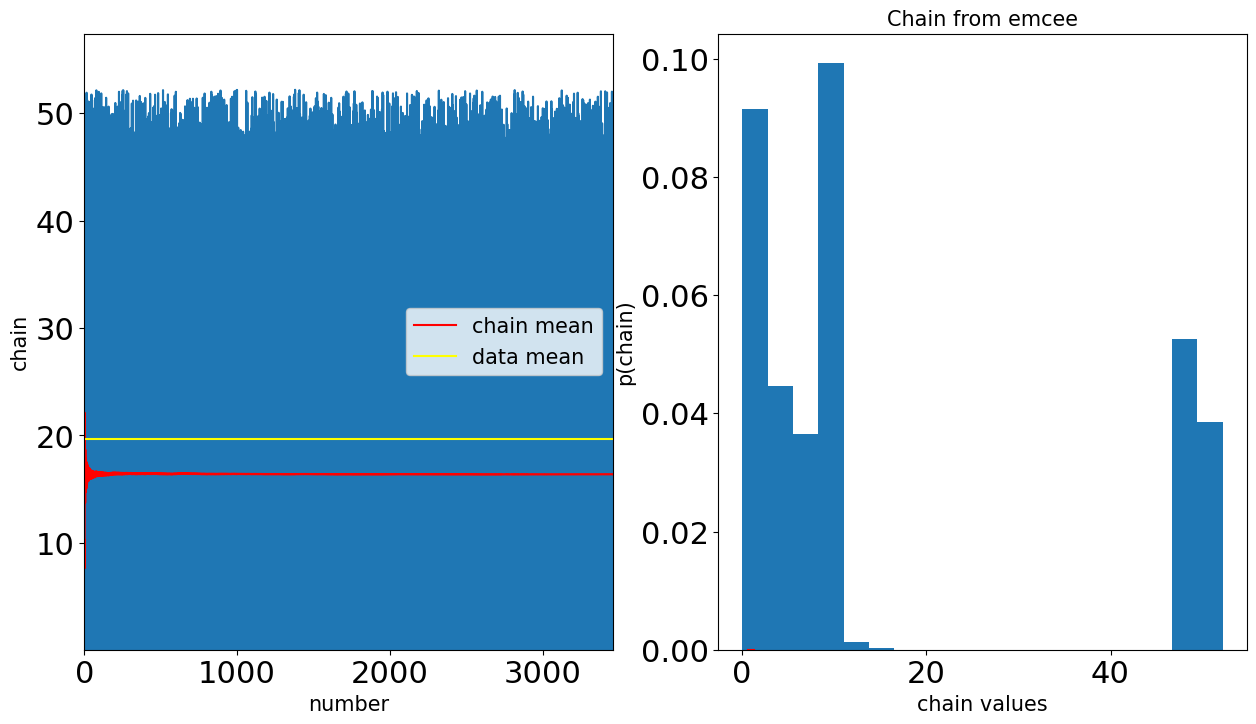

In [48]:
# plot 
plt.rcParams.update({'font.size': 22})

fig = plt.figure(figsize=(15, 8))
#fig.subplots_adjust(left=0.11, right=0.95, 
                   # wspace=0.35, bottom=0.18)

chainE = emcee_trace #[0]
M = np.size(chainE)

ax1 = fig.add_subplot(121)
xgrid = np.linspace(1, M, M)
plt.plot(xgrid, chainE)
ax1.axis([0, M, np.min(chainE), 1.1*np.max(chainE)])
plt.xlabel('number',fontsize=15)
plt.ylabel('chain',fontsize=15)

# plot running mean: 
meanC = [np.mean(chainE[:int(N)]) for N in xgrid]
ax1.plot(xgrid, meanC, c='red', label='chain mean') 
ax1.plot(xgrid, 0*xgrid + np.mean(data),
         c='yellow',label='data mean')
ax1.legend(fontsize=15)

ax2 = fig.add_subplot(122)
# skip first burn samples
Nburn = 1000
#Nchain = np.size(chainE[xgrid>burn])
Nhist, bins, patches = plt.hist(chainE, 
                                bins='auto', histtype='stepfilled',density=True)

# plot expectations based on central limit theorem
binwidth = bins[1] - bins[0]
muCLT = np.mean(data)
sigCLT = np.std(data)/np.sqrt(len(data))
muGrid = np.linspace(0.7, 1.3, 500)
gauss = stats.norm(muCLT, sigCLT).pdf(muGrid) 
ax2.plot(muGrid, gauss, c='red') 

ax2.set_ylabel('p(chain)',fontsize=15)
ax2.set_xlabel('chain values',fontsize=15)
#ax2.set_xlim(0.7, 1.3)
#ax2.set_ylim(0, 1.2*np.max(gauss))
ax2.set_title(r'Chain from emcee',fontsize=15)